In [4]:
import pandas as pd
from seismostats import Catalog
import matplotlib.pyplot as plt
import numpy as np
import warnings

from functions.main_functions import loglik_test, positive_cond_test

In [5]:
# paramters
delta_m = 0.01
dmc = 0.1
mc = 0.3


## get data

In [6]:
# ML high resoution catalog

location = 'data/testing/Amatrice_CAT5_test.csv'
cat_raw = pd.read_csv(location)

cat_test = Catalog(cat_raw)
cat_test.mc = mc
cat_test.delta_m = delta_m

In [7]:
from seismostats.utils import infer_binning
infer_binning(cat_test.magnitude)

0.01

<Axes: xlabel='Time', ylabel='Magnitude'>

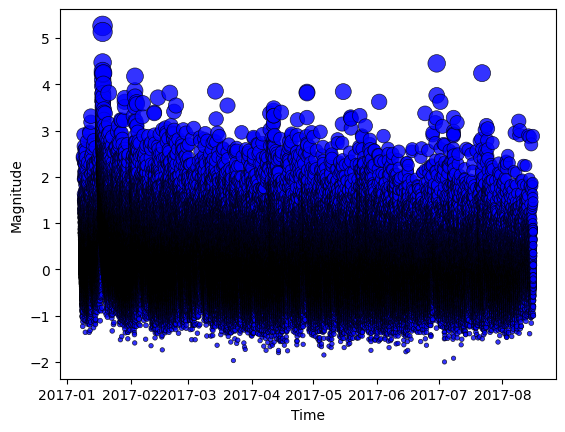

In [8]:
cat_test.plot_mags_in_time()

(-10.0, 35.0)

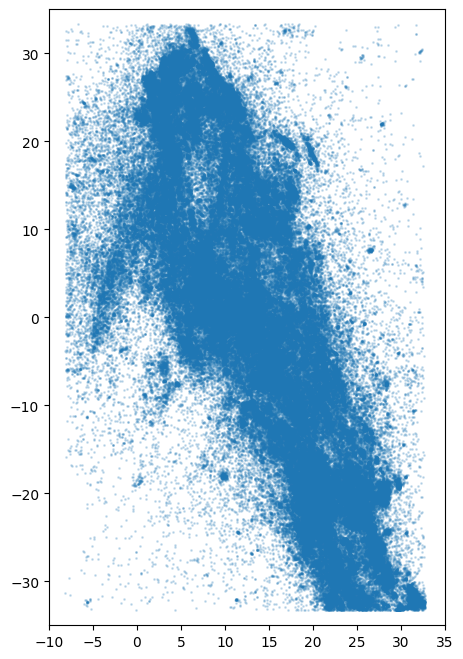

In [9]:
import numpy as np

# make ax cartopy geoaxis
import cartopy.crs as ccrs
fig = plt.figure(figsize=(12, 8))
plt.scatter(cat_test.y, cat_test.x, s=1, alpha=0.2)

#equal axis
plt.gca().set_aspect('equal', adjustable='box')

# limit depth to 30 km
plt.ylim(-35, 35)
# limit x to 20 km
plt.xlim(-10, 35)

(-10.0, 35.0)

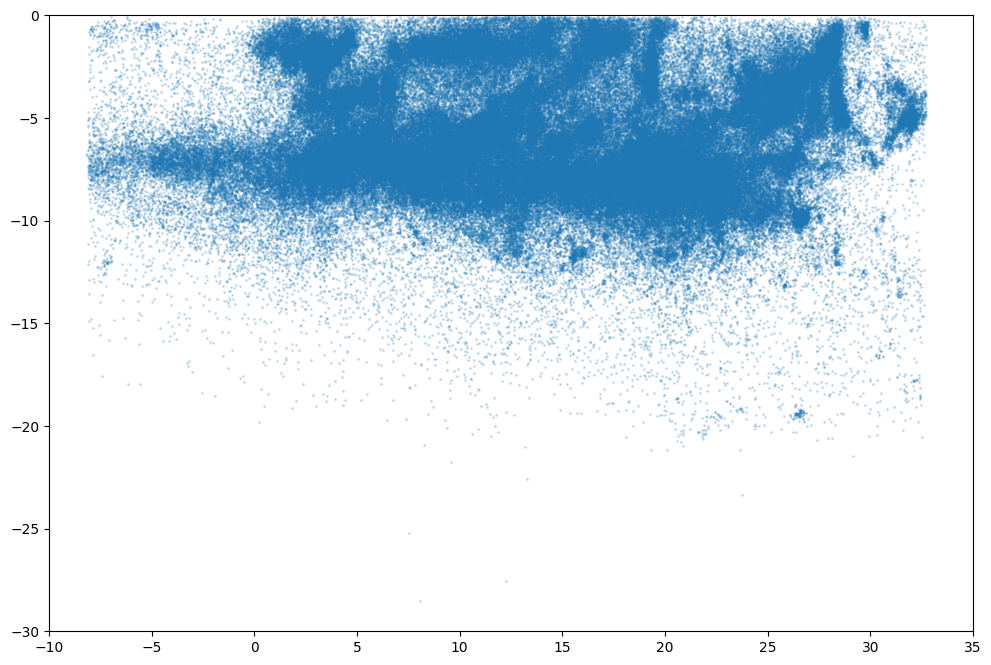

In [10]:
import numpy as np

# make ax cartopy geoaxis
import cartopy.crs as ccrs
fig = plt.figure(figsize=(12, 8))
plt.scatter(cat_test.y, cat_test.z, s=1, alpha=0.2)

#equal axis
plt.gca().set_aspect('equal', adjustable='box')

# limit depth to 30 km
plt.ylim(-30, 0)
# limit x to 20 km
plt.xlim(-10, 35)

Legend added to the plot.
Mc: 0.10


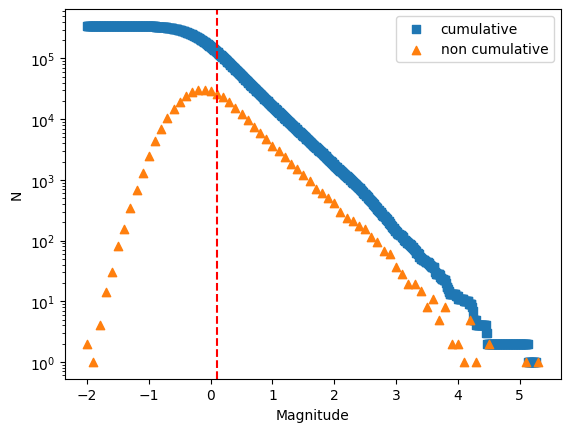

In [11]:
ax = cat_test.plot_cum_fmd()
cat_test.plot_fmd(ax = ax, fmd_bin=0.1)

cat_test.estimate_mc_maxc(fmd_bin=0.1)
plt.axvline(cat_test.mc, color='red', label='Mc', linestyle='--')

print(f'Mc: {cat_test.mc:.2f}')

# IG

In [12]:
from seismostats.utils import bin_to_precision
# sort in time 
cat_test = cat_test.sort_values('time').reset_index(drop=True)

# create the magnitude differences
cat_test['mag_diff'] = bin_to_precision(cat_test['magnitude'].diff(), delta_m)
nan_idx = cat_test['mag_diff'].isna()
cat_test = cat_test[~nan_idx]

In [10]:
import itertools
# 3D grid
# coords and limits
coords = [cat_test.x.values, cat_test.y.values, cat_test.z.values]

limits = [[min(coord), max(coord)] for coord in coords]

# create grid for evaluation
delta = 2 # in km
x_vec = np.arange(limits[0][0], limits[0][1], delta)
y_vec = np.arange(limits[1][0], limits[1][1], delta)
z_vec = np.arange(limits[2][0], limits[2][1], delta)

grid = np.array(list(itertools.product(x_vec, y_vec, z_vec)))
grid = grid.T

In [14]:
cat_test['mag_diff'] > dmc -   delta_m/2

1         False
2          True
3         False
4          True
5          True
          ...  
343943    False
343944     True
343945    False
343946    False
343947    False
Name: mag_diff, Length: 343947, dtype: bool